## DIGITAL BANKING CUSTOMER TRANSACTION ANALYTICS

In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("01_data/raw/bank_transactions_data_2_augmented_clean_2.csv")

In [5]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [6]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance'],
      dtype='object')

In [7]:
df.shape

(50000, 15)

In [8]:
df.info

<bound method DataFrame.info of       TransactionID AccountID  TransactionAmount   TransactionDate  \
0          TX000001   AC00128              14.09   4/11/2023 16:29   
1          TX000002   AC00455             376.24   6/27/2023 16:44   
2          TX000003   AC00019             126.29   7/10/2023 18:16   
3          TX000004   AC00070             184.50    5/5/2023 16:32   
4          TX000005   AC00411              13.45  10/16/2023 17:51   
...             ...       ...                ...               ...   
49995      TX049996   AC00314              69.23         1/28/2025   
49996      TX049997   AC00370             514.53         1/23/2022   
49997      TX049998   AC00277             118.39         11/8/2022   
49998      TX049999   AC00007             446.99         4/20/2025   
49999      TX050000   AC00427              84.82        11/19/2020   

      TransactionType   Location DeviceID       IP Address MerchantID Channel  \
0               Debit  San Diego  D000380   16

In [9]:
df.isnull().sum()

TransactionID          0
AccountID              0
TransactionAmount      0
TransactionDate        0
TransactionType        0
Location               0
DeviceID               0
IP Address             0
MerchantID             0
Channel                0
CustomerAge            0
CustomerOccupation     0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
dtype: int64

In [10]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,297.872214,44.647600,118.965320,1.12684,5122.738301
std,292.818888,17.800293,70.000681,0.60936,3904.266887
min,0.240000,18.000000,10.000000,1.00000,101.250000
25%,82.897500,27.000000,63.000000,1.00000,1508.720000
50%,209.355000,45.000000,111.000000,1.00000,4735.410000
75%,409.625000,59.000000,161.000000,1.00000,7713.670000
max,2060.590000,80.000000,300.000000,5.00000,14977.990000


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["TransactionID"].duplicated().sum()

np.int64(0)

In [13]:
df.dtypes

TransactionID           object
AccountID               object
TransactionAmount      float64
TransactionDate         object
TransactionType         object
Location                object
DeviceID                object
IP Address              object
MerchantID              object
Channel                 object
CustomerAge              int64
CustomerOccupation      object
TransactionDuration      int64
LoginAttempts            int64
AccountBalance         float64
dtype: object

In [26]:
df["Transaction Date"]=
pd.to_datetime(df["Transaction Date"],
errors='coerce')

SyntaxError: invalid syntax (1181842232.py, line 1)

In [19]:
df.dtypes

TransactionID           object
AccountID               object
TransactionAmount      float64
TransactionDate         object
TransactionType         object
Location                object
DeviceID                object
IP Address              object
MerchantID              object
Channel                 object
CustomerAge              int64
CustomerOccupation      object
TransactionDuration      int64
LoginAttempts            int64
AccountBalance         float64
dtype: object

In [28]:
df.columns.tolist()

['TransactionID',
 'AccountID',
 'TransactionAmount',
 'TransactionDate',
 'TransactionType',
 'Location',
 'DeviceID',
 'IP Address',
 'MerchantID',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

In [31]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

In [35]:
df['TransactionDate'].head()

0   2023-04-11 16:29:00
1   2023-06-27 16:44:00
2   2023-07-10 18:16:00
3   2023-05-05 16:32:00
4   2023-10-16 17:51:00
Name: TransactionDate, dtype: datetime64[ns]

In [36]:
df['TransactionDate'].isna().sum()

np.int64(43750)

-- DATE CONVERSION

In [37]:
df['TransactionDate'].head(10)

0   2023-04-11 16:29:00
1   2023-06-27 16:44:00
2   2023-07-10 18:16:00
3   2023-05-05 16:32:00
4   2023-10-16 17:51:00
5   2023-04-03 17:15:00
6   2023-02-15 16:36:00
7   2023-05-08 17:47:00
8   2023-03-21 16:59:00
9   2023-03-31 16:06:00
Name: TransactionDate, dtype: datetime64[ns]

In [38]:
df['TransactionDate'].isna().sum()

np.int64(43750)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   TransactionID        50000 non-null  object        
 1   AccountID            50000 non-null  object        
 2   TransactionAmount    50000 non-null  float64       
 3   TransactionDate      6250 non-null   datetime64[ns]
 4   TransactionType      50000 non-null  object        
 5   Location             50000 non-null  object        
 6   DeviceID             50000 non-null  object        
 7   IP Address           50000 non-null  object        
 8   MerchantID           50000 non-null  object        
 9   Channel              50000 non-null  object        
 10  CustomerAge          50000 non-null  int64         
 11  CustomerOccupation   50000 non-null  object        
 12  TransactionDuration  50000 non-null  int64         
 13  LoginAttempts        50000 non-

In [42]:
df['TransactionDate'] = pd.to_datetime(
    df['TransactionDate'],
    format='%Y-%m-%d %H:%M:%S'
)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   TransactionID        50000 non-null  object        
 1   AccountID            50000 non-null  object        
 2   TransactionAmount    50000 non-null  float64       
 3   TransactionDate      6250 non-null   datetime64[ns]
 4   TransactionType      50000 non-null  object        
 5   Location             50000 non-null  object        
 6   DeviceID             50000 non-null  object        
 7   IP Address           50000 non-null  object        
 8   MerchantID           50000 non-null  object        
 9   Channel              50000 non-null  object        
 10  CustomerAge          50000 non-null  int64         
 11  CustomerOccupation   50000 non-null  object        
 12  TransactionDuration  50000 non-null  int64         
 13  LoginAttempts        50000 non-

In [44]:
df['TransactionDate'].isna().sum()

np.int64(43750)

In [45]:
df[df['TransactionDate'].isna()].head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
6250,TX006251,AC00339,433.58,NaT,Debit,Colorado Springs,D000133,107.248.120.12,M064,Online,54,Engineer,285,1,8371.11
6251,TX006252,AC00006,156.58,NaT,Debit,Sacramento,D000027,218.238.171.184,M087,ATM,33,Doctor,100,1,5401.21
6252,TX006253,AC00030,370.85,NaT,Credit,Fort Worth,D000441,167.164.55.0,M043,Branch,26,Student,187,1,868.35
6253,TX006254,AC00475,192.37,NaT,Credit,Jacksonville,D000157,175.210.47.87,M091,Online,75,Retired,198,1,5029.87
6254,TX006255,AC00036,26.89,NaT,Debit,Indianapolis,D000687,49.20.211.229,M053,ATM,62,Retired,43,1,1674.94


In [46]:
df = pd.read_csv("01_data/raw/bank_transactions_data_2_augmented_clean_2.csv")

print(df['TransactionDate'].isna().sum())
print(df['TransactionDate'].head(10))

0
0     4/11/2023 16:29
1     6/27/2023 16:44
2     7/10/2023 18:16
3      5/5/2023 16:32
4    10/16/2023 17:51
5      4/3/2023 17:15
6     2/15/2023 16:36
7      5/8/2023 17:47
8     3/21/2023 16:59
9     3/31/2023 16:06
Name: TransactionDate, dtype: object


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  object 
 1   AccountID            50000 non-null  object 
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  object 
 4   TransactionType      50000 non-null  object 
 5   Location             50000 non-null  object 
 6   DeviceID             50000 non-null  object 
 7   IP Address           50000 non-null  object 
 8   MerchantID           50000 non-null  object 
 9   Channel              50000 non-null  object 
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  object 
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: float64(2), int64(3), object(10)


In [50]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

ValueError: time data "1/4/2024" doesn't match format "%m/%d/%Y %H:%M", at position 6250. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [51]:
df['TransactionDate'].head(20).tolist()

['4/11/2023 16:29',
 '6/27/2023 16:44',
 '7/10/2023 18:16',
 '5/5/2023 16:32',
 '10/16/2023 17:51',
 '4/3/2023 17:15',
 '2/15/2023 16:36',
 '5/8/2023 17:47',
 '3/21/2023 16:59',
 '3/31/2023 16:06',
 '3/14/2023 16:46',
 '2/6/2023 17:30',
 '6/7/2023 17:21',
 '11/20/2023 16:39',
 '2/13/2023 16:53',
 '12/12/2023 16:23',
 '10/30/2023 16:52',
 '12/14/2023 18:32',
 '2/21/2023 16:56',
 '6/8/2023 18:18']

In [52]:
df['TransactionDate'].dtype

dtype('O')

In [53]:
print(df['TransactionDate'].dtype)

object


In [54]:
print(df['TransactionDate'].head(10))

0     4/11/2023 16:29
1     6/27/2023 16:44
2     7/10/2023 18:16
3      5/5/2023 16:32
4    10/16/2023 17:51
5      4/3/2023 17:15
6     2/15/2023 16:36
7      5/8/2023 17:47
8     3/21/2023 16:59
9     3/31/2023 16:06
Name: TransactionDate, dtype: object


In [57]:
df['TransactionDate'] = pd.to_datetime(
    df['TransactionDate'],
    format='%m/%d/%Y %H:%M'
)

ValueError: time data "1/4/2024" doesn't match format "%m/%d/%Y %H:%M", at position 6250. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [58]:
pd.to_datetime(
    df['TransactionDate'],
    format='%m/%d/%Y %H:%M',
    errors='coerce'
).isna().sum()

np.int64(43750)

In [60]:
df['TransactionDate'].value_counts().head(20)

TransactionDate
6/12/2021     35
12/15/2025    34
1/13/2020     34
7/28/2022     34
8/8/2021      33
10/18/2021    33
8/22/2023     33
3/4/2023      32
12/5/2021     32
8/21/2024     32
12/7/2023     32
12/9/2022     32
1/2/2023      31
11/22/2022    31
6/10/2021     31
11/16/2022    31
6/26/2025     31
2/25/2024     31
11/22/2023    31
5/17/2025     31
Name: count, dtype: int64

In [59]:
df['TransactionDate'].iloc[6245:6260]

6245     8/6/2025 0:00
6246    12/7/2021 0:00
6247    3/22/2021 0:00
6248    4/11/2022 0:00
6249     3/4/2023 0:00
6250          1/4/2024
6251        12/30/2024
6252          5/7/2021
6253        10/26/2021
6254         8/19/2025
6255         8/22/2022
6256         6/13/2021
6257        11/30/2025
6258         9/11/2022
6259        11/29/2025
Name: TransactionDate, dtype: object

In [61]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'],format='mixed')

In [62]:
df['TransactionDate'].isna().sum()

np.int64(0)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   TransactionID        50000 non-null  object        
 1   AccountID            50000 non-null  object        
 2   TransactionAmount    50000 non-null  float64       
 3   TransactionDate      50000 non-null  datetime64[ns]
 4   TransactionType      50000 non-null  object        
 5   Location             50000 non-null  object        
 6   DeviceID             50000 non-null  object        
 7   IP Address           50000 non-null  object        
 8   MerchantID           50000 non-null  object        
 9   Channel              50000 non-null  object        
 10  CustomerAge          50000 non-null  int64         
 11  CustomerOccupation   50000 non-null  object        
 12  TransactionDuration  50000 non-null  int64         
 13  LoginAttempts        50000 non-

In [64]:
df.isnull().sum()

TransactionID          0
AccountID              0
TransactionAmount      0
TransactionDate        0
TransactionType        0
Location               0
DeviceID               0
IP Address             0
MerchantID             0
Channel                0
CustomerAge            0
CustomerOccupation     0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
dtype: int64

In [3]:
df.isnull().sum()

NameError: name 'df' is not defined

In [5]:
import pandas as pd

df = pd.read_csv("01_Data/raw/bank_transactions_data_2_augmented_clean_2.csv")

In [6]:
df.shape

(50000, 15)

In [8]:
df['TransactionDate'] = pd.to_datetime(
    df['TransactionDate'],
    format='mixed'
)

In [9]:
df['TransactionDate'].isna().sum()

np.int64(0)

In [10]:
df.isnull().sum()

TransactionID          0
AccountID              0
TransactionAmount      0
TransactionDate        0
TransactionType        0
Location               0
DeviceID               0
IP Address             0
MerchantID             0
Channel                0
CustomerAge            0
CustomerOccupation     0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

TransactionID                  object
AccountID                      object
TransactionAmount             float64
TransactionDate        datetime64[ns]
TransactionType                object
Location                       object
DeviceID                       object
IP Address                     object
MerchantID                     object
Channel                        object
CustomerAge                     int64
CustomerOccupation             object
TransactionDuration             int64
LoginAttempts                   int64
AccountBalance                float64
dtype: object

In [13]:
df[['TransactionAmount','CustomerAge','TransactionDuration','LoginAttempts','AccountBalance']].describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,297.872214,44.647600,118.965320,1.12684,5122.738301
std,292.818888,17.800293,70.000681,0.60936,3904.266887
min,0.240000,18.000000,10.000000,1.00000,101.250000
25%,82.897500,27.000000,63.000000,1.00000,1508.720000
50%,209.355000,45.000000,111.000000,1.00000,4735.410000
75%,409.625000,59.000000,161.000000,1.00000,7713.670000
max,2060.590000,80.000000,300.000000,5.00000,14977.990000


In [20]:
print("Negative Transaction Amounts:",
      (df['TransactionAmount'] < 0).sum())

print("Invalid Ages:",
      ((df['CustomerAge'] < 18) | (df['CustomerAge'] > 100)).sum())

print("Invalid Login Attempts:",
      (df['LoginAttempts'] < 1).sum())

print("Negative Account Balances:",
      (df['AccountBalance'] < 0).sum())

Negative Transaction Amounts: 0
Invalid Ages: 0
Invalid Login Attempts: 0
Negative Account Balances: 0


## TRANSACTIONS BEHAVIOUR

In [21]:
df['TransactionType'].value_counts()

TransactionType
Debit     38747
Credit    11253
Name: count, dtype: int64

In [22]:
df['Channel'].value_counts()

Channel
Branch    17278
ATM       16552
Online    16170
Name: count, dtype: int64

In [23]:
df['CustomerOccupation'].value_counts()

CustomerOccupation
Student     13059
Doctor      12578
Engineer    12491
Retired     11872
Name: count, dtype: int64

## TRANSACTION AMOUNT ANALYSIS


In [ ]:
df.groupby('TransactionType')['TransactionAmount'].sum()

TransactionType
Credit     3432251.62
Debit     11461359.07
Name: TransactionAmount, dtype: float64

In [35]:
df.groupby('TransactionType')['TransactionAmount'].mean()

TransactionType
Credit    305.007698
Debit     295.799909
Name: TransactionAmount, dtype: float64

In [36]:
df.groupby('TransactionType')['TransactionAmount'].count()

TransactionType
Credit    11253
Debit     38747
Name: TransactionAmount, dtype: int64

## INSIGHTS
1. Debit dominates tranaction volume -- 38,747 transactions
2. debit also has the much higher total transaction value because of its much larger volume.
3. credit has a slightly higher average transaction amount(305.81 vs 295.80)

## CHANNEL ANALYSIS

In [45]:
df.groupby('Channel')['TransactionAmount'].sum()

Channel
ATM       5016227.33
Branch    5044812.38
Online    4832570.98
Name: TransactionAmount, dtype: float64

In [46]:
df.groupby('Channel')['TransactionAmount'].mean()

Channel
ATM       303.058684
Branch    291.978955
Online    298.860296
Name: TransactionAmount, dtype: float64

In [47]:
df.groupby('Channel')['TransactionAmount'].count()

Channel
ATM       16552
Branch    17278
Online    16170
Name: TransactionAmount, dtype: int64

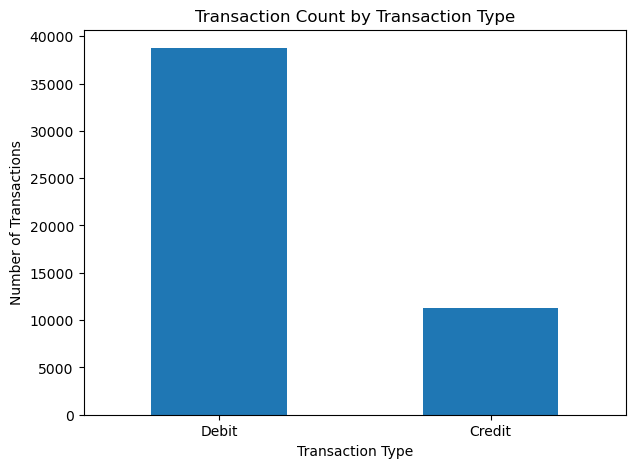

In [ ]:
## CREDIT VS DEBIT TRANSACTION COUNT

import matplotlib.pyplot as plt

transaction_counts = df['TransactionType'].value_counts()

plt.figure(figsize=(7,5))
transaction_counts.plot(kind='bar')

plt.title('Transaction Count by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.show()

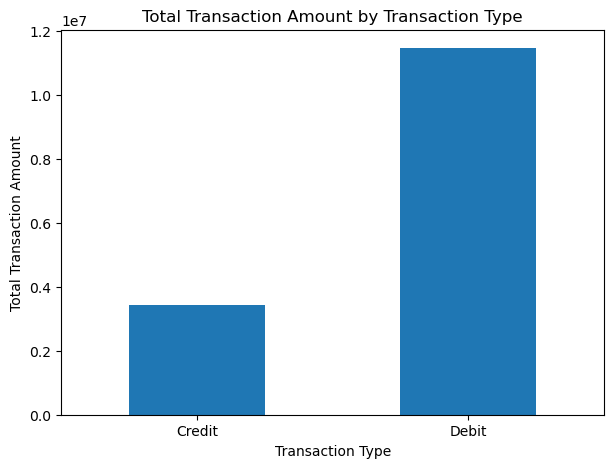

In [ ]:
## TOTAL TRANSACTION AMOUNT

transaction_amount = df.groupby('TransactionType')['TransactionAmount'].sum()

plt.figure(figsize=(7,5))
transaction_amount.plot(kind='bar')

plt.title('Total Transaction Amount by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Total Transaction Amount')
plt.xticks(rotation=0)
plt.show()

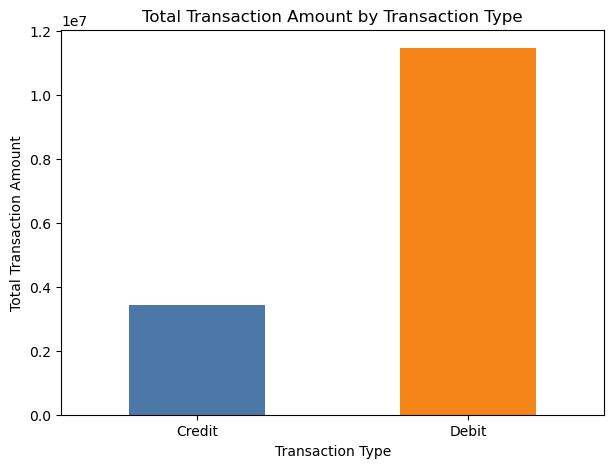

In [50]:
transaction_amount = df.groupby('TransactionType')['TransactionAmount'].sum()

plt.figure(figsize=(7,5))

transaction_amount.plot(
    kind='bar',
    color=['#4C78A8', '#F58518']
)

plt.title('Total Transaction Amount by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Total Transaction Amount')
plt.xticks(rotation=0)
plt.show()

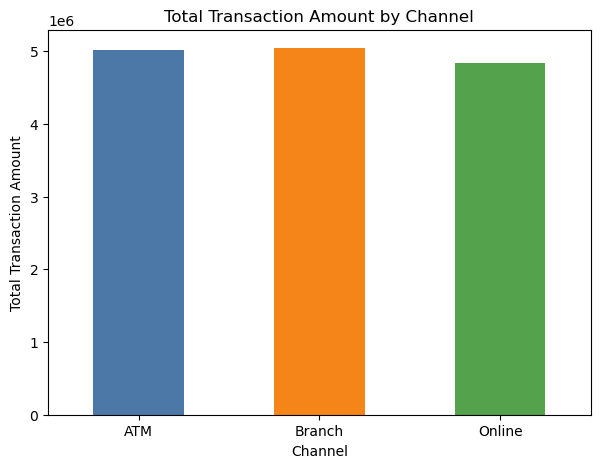

In [51]:
channel_amount = df.groupby('Channel')['TransactionAmount'].sum()

plt.figure(figsize=(7,5))

channel_amount.plot(
    kind='bar',
    color=['#4C78A8', '#F58518', '#54A24B']
)

plt.title('Total Transaction Amount by Channel')
plt.xlabel('Channel')
plt.ylabel('Total Transaction Amount')
plt.xticks(rotation=0)
plt.show()

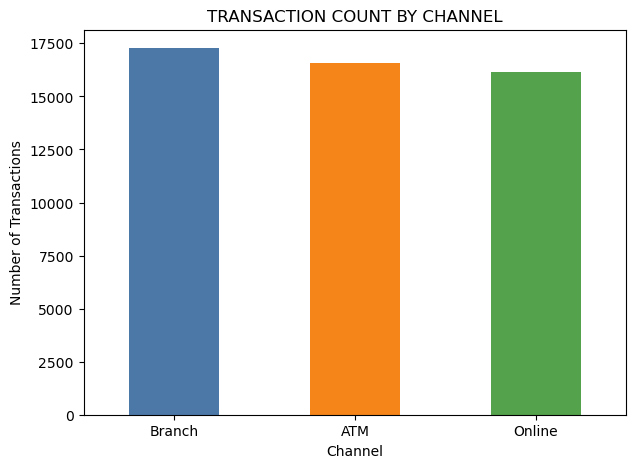

In [54]:
channel_count = df['Channel'].value_counts()

plt.figure(figsize=(7,5))

channel_count.plot(
    kind='bar',
    color=['#4C78A8', '#F58518', '#54A24B']
)

plt.title('TRANSACTION COUNT BY CHANNEL')
plt.xlabel('Channel')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.show()

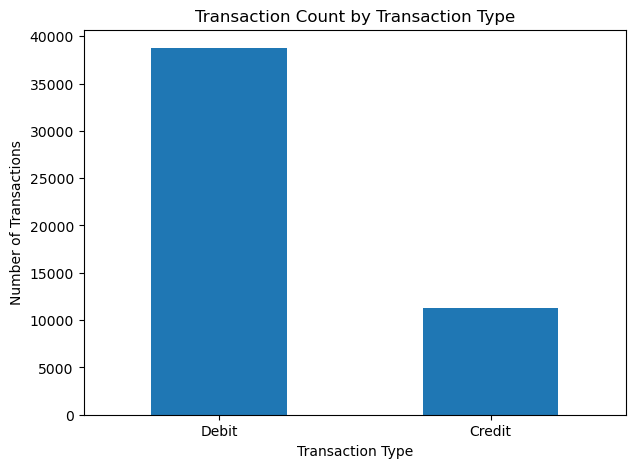

In [58]:
import matplotlib.pyplot as plt

transaction_counts = df['TransactionType'].value_counts()

plt.figure(figsize=(7,5))
transaction_counts.plot(kind='bar')

plt.title('Transaction Count by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.show()

In [59]:
df['AgeGroup'] = pd.cut(
    df['CustomerAge'],
    bins=[17, 25, 35, 45, 55, 65, 80],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66-80']
)

df['AgeGroup'].value_counts().sort_index()

AgeGroup
18-25    9501
26-35    9734
36-45    6009
46-55    8454
56-65    8993
66-80    7309
Name: count, dtype: int64

In [63]:
age_count = df.groupby('AgeGroup', observed=False)['TransactionAmount'].count()

age_count

AgeGroup
18-25    9501
26-35    9734
36-45    6009
46-55    8454
56-65    8993
66-80    7309
Name: TransactionAmount, dtype: int64

In [64]:
## TOTAL TRANSACTION VALUE
age_amount = df.groupby('AgeGroup', observed=False)['TransactionAmount'].sum()

age_amount

AgeGroup
18-25    3009584.98
26-35    2944042.45
36-45    1716842.31
46-55    2331526.85
56-65    2763438.63
66-80    2128175.47
Name: TransactionAmount, dtype: float64

In [65]:
## average transaction value
age_avg = df.groupby('AgeGroup', observed=False)['TransactionAmount'].mean()

age_avg

AgeGroup
18-25    316.765075
26-35    302.449399
36-45    285.711817
46-55    275.789786
56-65    307.287738
66-80    291.171907
Name: TransactionAmount, dtype: float64

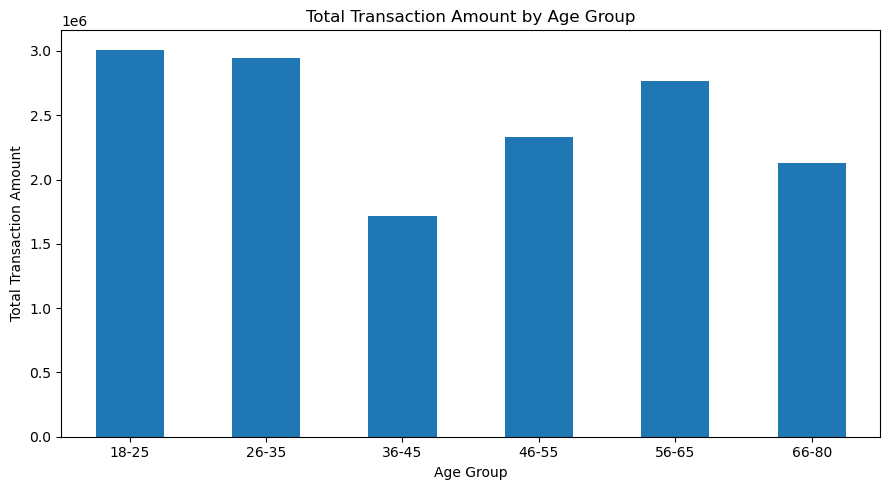

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

age_amount.plot(kind='bar')

plt.title('Total Transaction Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Transaction Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## CUSTOMER OCCUPATION ANALYSIS


In [70]:
Occupation_count =
df.groupby('customerOccupation')
['TransactionAmount'].count()
occupation_count

SyntaxError: invalid syntax (1078813149.py, line 1)

In [71]:
occupation_count = df.groupby('CustomerOccupation')['TransactionAmount'].count()
occupation_count

CustomerOccupation
Doctor      12578
Engineer    12491
Retired     11872
Student     13059
Name: TransactionAmount, dtype: int64

In [72]:
occupation_amount = df.groupby('CustomerOccupation')['TransactionAmount'].sum()
occupation_amount

CustomerOccupation
Doctor      3662896.27
Engineer    3604118.70
Retired     3537117.07
Student     4089478.65
Name: TransactionAmount, dtype: float64

In [73]:
## AVERAGE TRANSACTION AMOUNT
occupation_avg = df.groupby('CustomerOccupation')['TransactionAmount'].mean()
occupation_avg

CustomerOccupation
Doctor      291.214523
Engineer    288.537243
Retired     297.937759
Student     313.154043
Name: TransactionAmount, dtype: float64

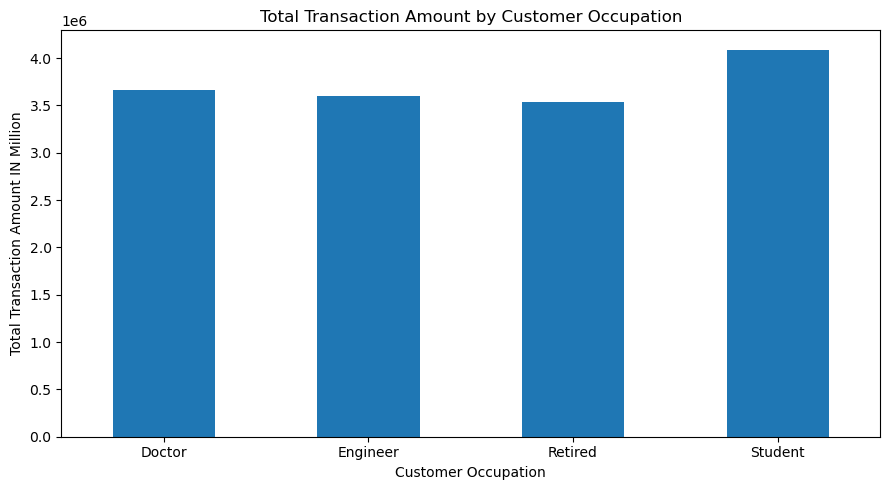

In [75]:
## GRAPH
plt.figure(figsize=(9,5))

occupation_amount.plot(kind='bar')

plt.title('Total Transaction Amount by Customer Occupation')
plt.xlabel('Customer Occupation')
plt.ylabel('Total Transaction Amount IN Million')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [76]:
## LOCATION ANALYSIS

location_analysis = df.groupby('Location').agg(
    Transaction_Count=('TransactionAmount', 'count'),
    Total_Amount=('TransactionAmount', 'sum'),
    Average_Amount=('TransactionAmount', 'mean')
).sort_values('Total_Amount', ascending=False)

location_analysis

,Transaction_Count,Total_Amount,Average_Amount
Location,,,
Austin,1146,453508.80,395.731937
Memphis,1330,445646.01,335.072188
Oklahoma City,1345,444559.54,330.527539
San Antonio,1195,423005.49,353.979490
Fort Worth,1396,422279.87,302.492744
Jacksonville,1216,411470.80,338.380592
Phoenix,1155,410725.84,355.606788
Tucson,1322,401159.06,303.448608
Detroit,1230,396371.02,322.252862


In [77]:
location_analysis.head(10)

,Transaction_Count,Total_Amount,Average_Amount
Location,,,
Austin,1146,453508.80,395.731937
Memphis,1330,445646.01,335.072188
Oklahoma City,1345,444559.54,330.527539
San Antonio,1195,423005.49,353.979490
Fort Worth,1396,422279.87,302.492744
Jacksonville,1216,411470.80,338.380592
Phoenix,1155,410725.84,355.606788
Tucson,1322,401159.06,303.448608
Detroit,1230,396371.02,322.252862


## LOCATION ANALYSIS INSIGHT
Austin is #1 in total transaction value AND has the highest average transaction amount (₹395.73) among these All the locations.

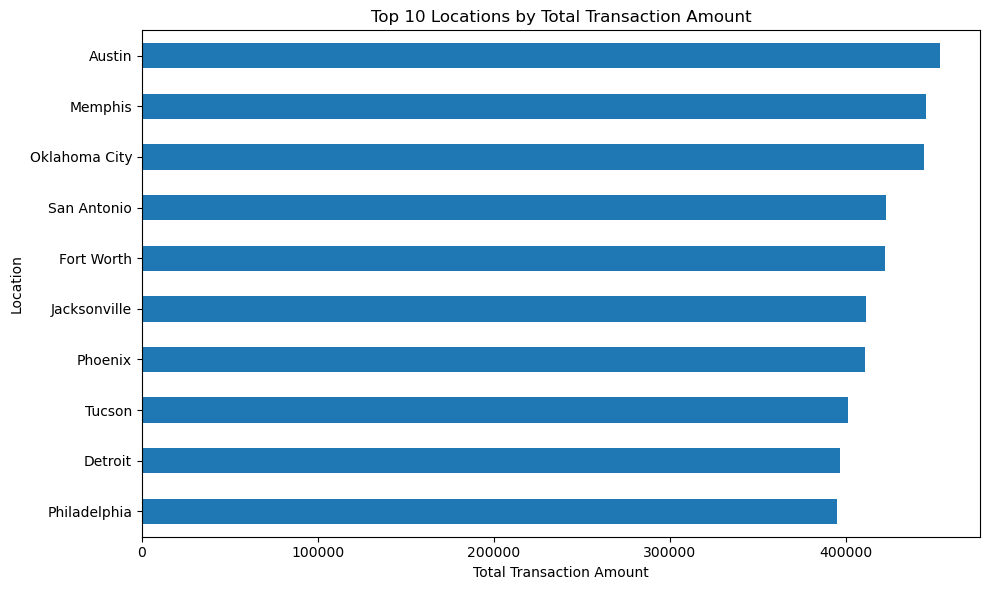

In [78]:
import matplotlib.pyplot as plt

top_locations = location_analysis.head(10)

plt.figure(figsize=(10,6))

top_locations['Total_Amount'].sort_values().plot(kind='barh')

plt.title('Top 10 Locations by Total Transaction Amount')
plt.xlabel('Total Transaction Amount')
plt.ylabel('Location')

plt.tight_layout()
plt.show()

In [82]:
## TIME BASED TRANSACTION ANALYSIS
df['year']=df['TransactionDate'].dt.year
df['Month']=df['TransactionDate'].dt.month
df['MonthName']= df['TransactionDate'].dt.month_name()


In [83]:
df[['TransactionDate', 'Year', 'Month', 'MonthName']].head()

,TransactionDate,Year,Month,MonthName
0,2023-04-11 16:29:00,2023,4,April
1,2023-06-27 16:44:00,2023,6,June
2,2023-07-10 18:16:00,2023,7,July
3,2023-05-05 16:32:00,2023,5,May
4,2023-10-16 17:51:00,2023,10,October


In [84]:
year_analysis = df.groupby('Year').agg(
    Transaction_Count=('TransactionAmount', 'count'),
    Total_Amount=('TransactionAmount', 'sum'),
    Average_Amount=('TransactionAmount', 'mean')
)

year_analysis

,Transaction_Count,Total_Amount,Average_Amount
Year,,,
2020,7995,2335094.26,292.069326
2021,7913,2374930.81,300.130268
2022,7789,2318161.27,297.619883
2023,10436,3087656.98,295.865943
2024,7971,2400796.59,301.191393
2025,7896,2376970.78,301.034800


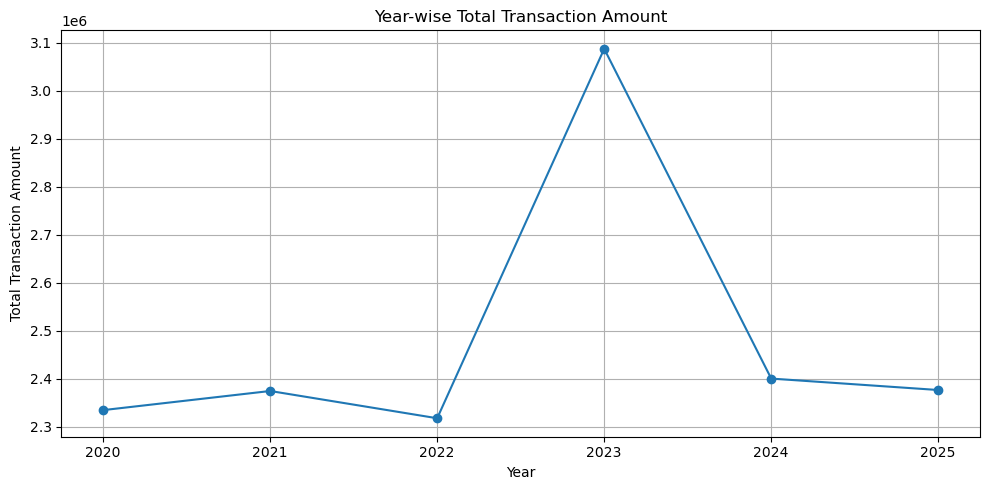

In [85]:
plt.figure(figsize=(10,5))

year_analysis['Total_Amount'].plot(
    kind='line',
    marker='o'
)

plt.title('Year-wise Total Transaction Amount')
plt.xlabel('Year')
plt.ylabel('Total Transaction Amount')
plt.grid(True)
plt.tight_layout()
plt.show()

In [86]:
## MONTHLY TRANSACTION ANALYSIS
monthly_analysis = df.groupby('Month').agg(
    Transaction_Count=('TransactionAmount', 'count'),
    Total_Amount=('TransactionAmount', 'sum'),
    Average_Amount=('TransactionAmount', 'mean')
)

monthly_analysis

,Transaction_Count,Total_Amount,Average_Amount
Month,,,
1,4336,1277125.46,294.540005
2,3894,1170807.23,300.669551
3,4221,1270873.21,301.083442
4,3991,1165548.42,292.044204
5,4185,1270332.00,303.544086
6,4056,1199823.39,295.814445
7,4172,1260540.64,302.143011
8,4338,1295119.25,298.552155
9,4134,1244302.09,300.992281


In [87]:
## FIND THE HIGHEST MONTH
monthly_analysis.sort_values('Total_Amount', ascending=False).head(5)

,Transaction_Count,Total_Amount,Average_Amount
Month,,,
8,4338,1295119.25,298.552155
10,4312,1278181.09,296.424186
1,4336,1277125.46,294.540005
3,4221,1270873.21,301.083442
5,4185,1270332.00,303.544086


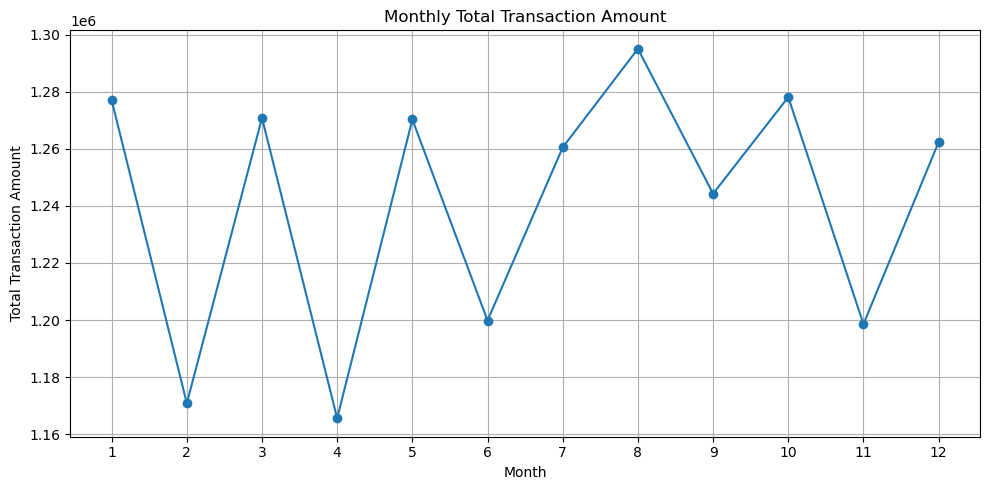

In [90]:
plt.figure(figsize=(10,5))

monthly_analysis['Total_Amount'].plot(
    kind='line',
    marker='o'
)

plt.title('Monthly Total Transaction Amount')
plt.xlabel('Month')
plt.ylabel('Total Transaction Amount')
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

## BANKING RISK & FRAUD INDICATORS

In [91]:
high_value_threshold = df['TransactionAmount'].quantile(0.95)

df['HighValueFlag'] = (
    df['TransactionAmount'] >= high_value_threshold
).astype(int)

print("High-value threshold:", high_value_threshold)
print(df['HighValueFlag'].value_counts())

High-value threshold: 884.5459999999995
HighValueFlag
0    47500
1     2500
Name: count, dtype: int64


In [92]:
df['MultipleLoginFlag'] = (
    df['LoginAttempts'] > 1
).astype(int)

print(df['MultipleLoginFlag'].value_counts())

MultipleLoginFlag
0    47547
1     2453
Name: count, dtype: int64


In [93]:
duration_threshold = df['TransactionDuration'].quantile(0.95)

df['LongDurationFlag'] = (
    df['TransactionDuration'] >= duration_threshold
).astype(int)

print("Duration threshold:", duration_threshold)
print(df['LongDurationFlag'].value_counts())

Duration threshold: 265.0
LongDurationFlag
0    47434
1     2566
Name: count, dtype: int64


In [94]:
df['RiskScore'] = (
    df['HighValueFlag'] +
    df['MultipleLoginFlag'] +
    df['LongDurationFlag']
)

df['RiskScore'].value_counts().sort_index()

RiskScore
0    42884
1     6713
2      403
Name: count, dtype: int64

In [95]:
df['RiskCategory'] = pd.cut(
    df['RiskScore'],
    bins=[-1, 0, 1, 3],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

df['RiskCategory'].value_counts()

RiskCategory
Low Risk       42884
Medium Risk     6713
High Risk        403
Name: count, dtype: int64

In [96]:
risk_channel = pd.crosstab(
    df['Channel'],
    df['RiskCategory'],
    normalize='index'
) * 100

risk_channel

RiskCategory,Low Risk,Medium Risk,High Risk
Channel,,,
ATM,85.705655,13.611648,0.682697
Branch,86.966084,11.870587,1.163329
Online,84.551639,14.897959,0.550402


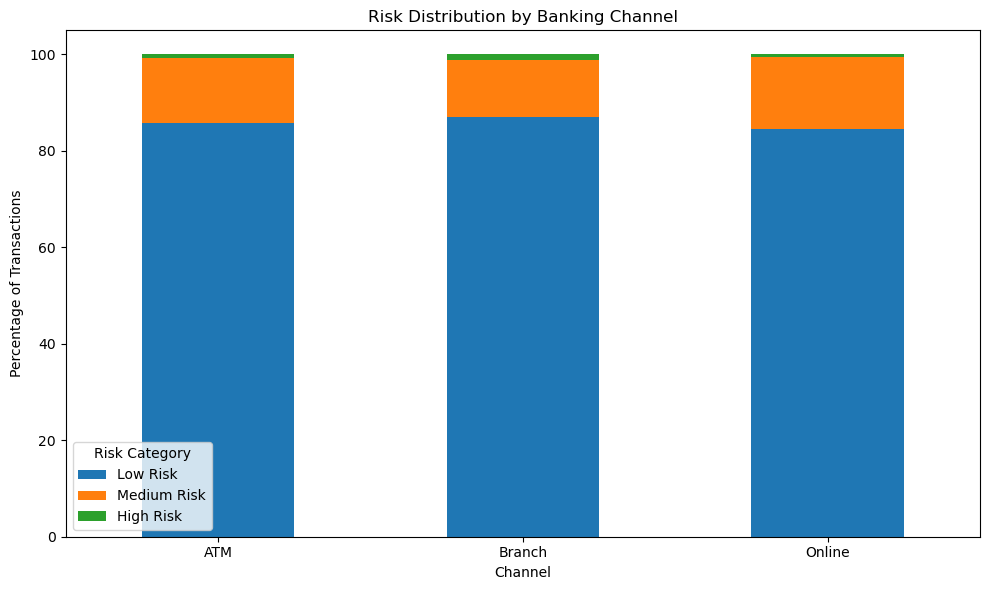

In [97]:
risk_channel.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Risk Distribution by Banking Channel')
plt.xlabel('Channel')
plt.ylabel('Percentage of Transactions')
plt.xticks(rotation=0)
plt.legend(title='Risk Category')
plt.tight_layout()
plt.show()

In [98]:
high_risk = df[df['RiskScore'] >= 2].sort_values(
    'RiskScore',
    ascending=False
)

high_risk[
    [
        'TransactionID',
        'TransactionAmount',
        'TransactionType',
        'Channel',
        'CustomerAge',
        'TransactionDuration',
        'LoginAttempts',
        'RiskScore',
        'RiskCategory'
    ]
].head(20)

,TransactionID,TransactionAmount,TransactionType,Channel,CustomerAge,TransactionDuration,LoginAttempts,RiskScore,RiskCategory
146,TX000147,973.39,Debit,Branch,77,296,1,2,High Risk
33723,TX033724,944.24,Debit,Branch,77,296,1,2,High Risk
34522,TX034523,88.75,Debit,Branch,27,291,4,2,High Risk
34469,TX034470,901.37,Debit,Branch,77,296,1,2,High Risk
34445,TX034446,49.15,Credit,Branch,29,275,4,2,High Risk
34420,TX034421,71.50,Debit,Branch,69,280,2,2,High Risk
34182,TX034183,1014.23,Debit,Branch,77,296,1,2,High Risk
33954,TX033955,75.24,Debit,ATM,44,274,2,2,High Risk
33922,TX033923,1607.49,Debit,Online,18,62,4,2,High Risk
33903,TX033904,1611.40,Debit,Online,18,62,4,2,High Risk


In [99]:
login_analysis = df['LoginAttempts'].value_counts().sort_index()

login_analysis

LoginAttempts
1    47547
2      529
3      619
4      645
5      660
Name: count, dtype: int64

In [100]:
login_behavior = df.groupby('LoginAttempts').agg(
    Transaction_Count=('TransactionAmount', 'count'),
    Total_Amount=('TransactionAmount', 'sum'),
    Average_Amount=('TransactionAmount', 'mean')
)

login_behavior

,Transaction_Count,Total_Amount,Average_Amount
LoginAttempts,,,
1,47547,14207031.35,298.799742
2,529,166829.10,315.366919
3,619,165811.03,267.869192
4,645,161023.55,249.648915
5,660,192915.66,292.296455


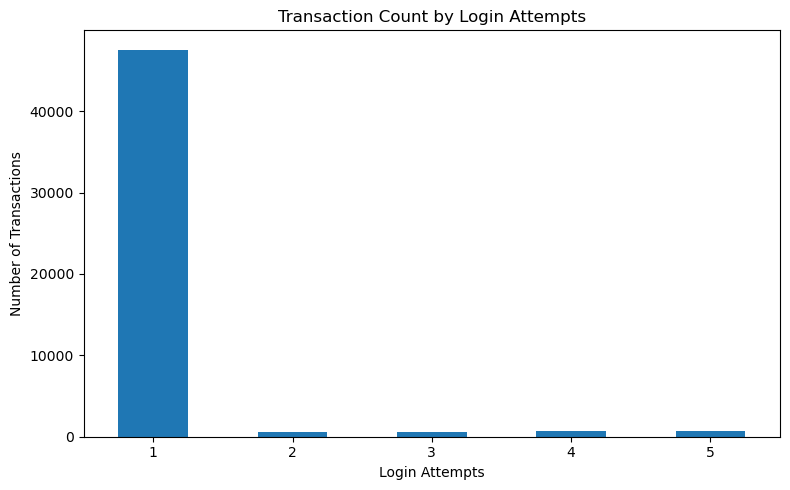

In [101]:
plt.figure(figsize=(8,5))

login_behavior['Transaction_Count'].plot(
    kind='bar'
)

plt.title('Transaction Count by Login Attempts')
plt.xlabel('Login Attempts')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [102]:
df['HighLoginAttemptFlag'] = (
    df['LoginAttempts'] >= 3
).astype(int)

df['HighLoginAttemptFlag'].value_counts()

HighLoginAttemptFlag
0    48076
1     1924
Name: count, dtype: int64

In [103]:
high_login = df[df['HighLoginAttemptFlag'] == 1]

high_login[
    [
        'TransactionID',
        'TransactionAmount',
        'TransactionType',
        'Channel',
        'CustomerAge',
        'LoginAttempts',
        'TransactionDuration',
        'AccountBalance'
    ]
].head(20)

,TransactionID,TransactionAmount,TransactionType,Channel,CustomerAge,LoginAttempts,TransactionDuration,AccountBalance
23,TX000024,345.84,Debit,Online,22,3,142,1402.50
26,TX000027,246.93,Debit,ATM,23,5,158,673.35
32,TX000033,396.45,Debit,ATM,49,3,168,9690.15
91,TX000092,223.85,Debit,ATM,53,4,55,2929.91
147,TX000148,514.95,Debit,Online,41,5,142,421.93
231,TX000232,705.60,Debit,Branch,40,3,124,14804.70
266,TX000267,66.90,Credit,Online,79,4,129,5238.71
274,TX000275,1176.28,Credit,ATM,54,5,174,323.69
356,TX000357,121.82,Debit,Online,69,3,123,8354.54
394,TX000395,6.30,Debit,Branch,80,5,283,7697.68


In [104]:
risk_by_channel = df.groupby('Channel').agg(
    Transaction_Count=('TransactionID', 'count'),
    High_Risk_Count=('RiskScore', lambda x: (x >= 2).sum()),
    Average_Risk_Score=('RiskScore', 'mean')
)

risk_by_channel['High_Risk_Percentage'] = (
    risk_by_channel['High_Risk_Count']
    / risk_by_channel['Transaction_Count']
    * 100
)

risk_by_channel.sort_values(
    'High_Risk_Percentage',
    ascending=False
)

,Transaction_Count,High_Risk_Count,Average_Risk_Score,High_Risk_Percentage
Channel,,,,
Branch,17278,201,0.141972,1.163329
ATM,16552,113,0.149770,0.682697
Online,16170,89,0.159988,0.550402


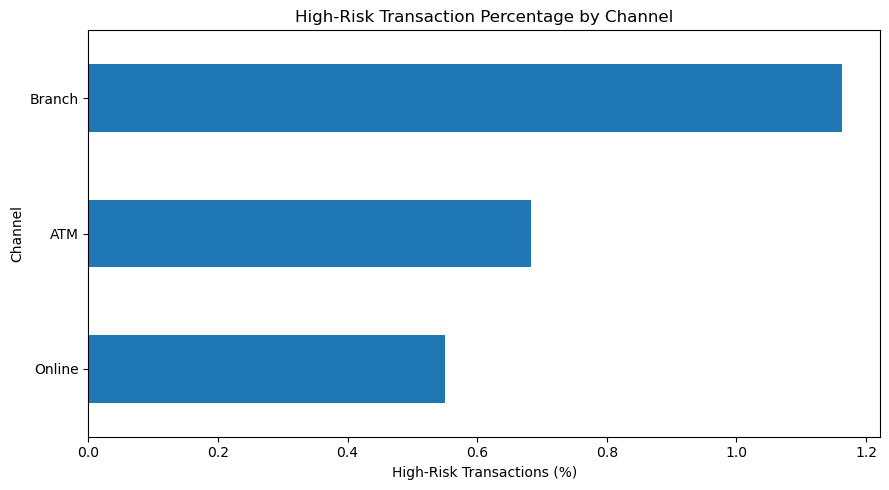

In [105]:
plt.figure(figsize=(9,5))

risk_by_channel['High_Risk_Percentage'].sort_values().plot(
    kind='barh'
)

plt.title('High-Risk Transaction Percentage by Channel')
plt.xlabel('High-Risk Transactions (%)')
plt.ylabel('Channel')

plt.tight_layout()
plt.show()

In [106]:
risk_by_type = df.groupby('TransactionType').agg(
    Transaction_Count=('TransactionID', 'count'),
    High_Risk_Count=('RiskScore', lambda x: (x >= 2).sum()),
    Average_Risk_Score=('RiskScore', 'mean')
)

risk_by_type['High_Risk_Percentage'] = (
    risk_by_type['High_Risk_Count']
    / risk_by_type['Transaction_Count']
    * 100
)

risk_by_type

,Transaction_Count,High_Risk_Count,Average_Risk_Score,High_Risk_Percentage
TransactionType,,,,
Credit,11253,94,0.146006,0.835333
Debit,38747,309,0.151650,0.797481


In [107]:
risk_by_channel

,Transaction_Count,High_Risk_Count,Average_Risk_Score,High_Risk_Percentage
Channel,,,,
ATM,16552,113,0.149770,0.682697
Branch,17278,201,0.141972,1.163329
Online,16170,89,0.159988,0.550402


In [108]:
risk_summary = df['RiskCategory'].value_counts()

risk_summary

RiskCategory
Low Risk       42884
Medium Risk     6713
High Risk        403
Name: count, dtype: int64

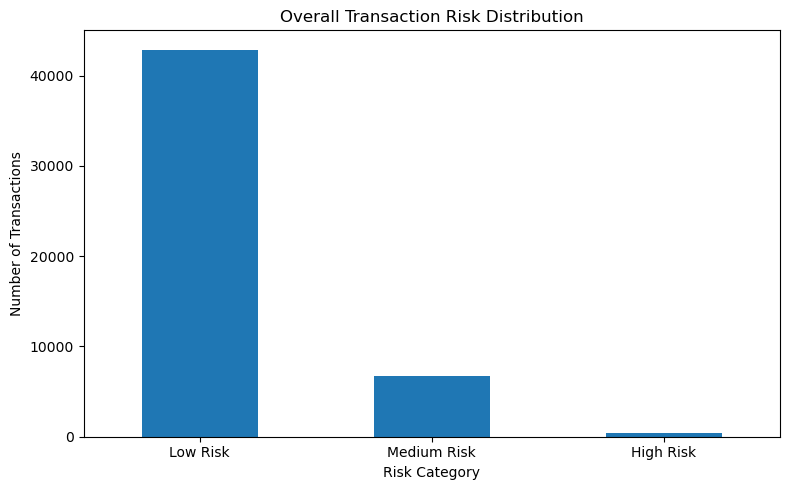

In [109]:
plt.figure(figsize=(8,5))

risk_summary.plot(kind='bar')

plt.title('Overall Transaction Risk Distribution')
plt.xlabel('Risk Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [110]:
risk_summary

RiskCategory
Low Risk       42884
Medium Risk     6713
High Risk        403
Name: count, dtype: int64

In [112]:
risk_percentage = (
    df['RiskCategory']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

risk_percentage

RiskCategory
Low Risk       85.77
Medium Risk    13.43
High Risk       0.81
Name: proportion, dtype: float64

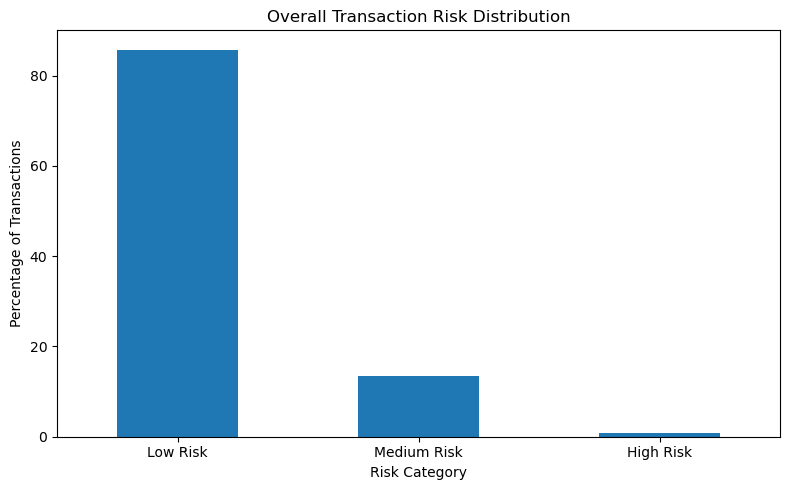

In [113]:
plt.figure(figsize=(8,5))

risk_percentage.plot(kind='bar')

plt.title('Overall Transaction Risk Distribution')
plt.xlabel('Risk Category')
plt.ylabel('Percentage of Transactions')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [114]:
high_risk_count = (df['RiskScore'] >= 2).sum()

print("Potentially High-Risk Transactions:", high_risk_count)
print(
    "High-Risk Percentage:",
    round(high_risk_count / len(df) * 100, 2),
    "%"
)

Potentially High-Risk Transactions: 403
High-Risk Percentage: 0.81 %


In [116]:
customer_analysis = df.groupby('AccountID').agg(
    Transaction_Count=('TransactionID', 'count'),
    Total_Transaction_Amount=('TransactionAmount', 'sum'),
    Average_Transaction_Amount=('TransactionAmount', 'mean'),
    Average_Account_Balance=('AccountBalance', 'mean')
).sort_values(
    'Total_Transaction_Amount',
    ascending=False
)

customer_analysis.head(10)

,Transaction_Count,Total_Transaction_Amount,Average_Transaction_Amount,Average_Account_Balance
AccountID,,,,
AC00460,238,111652.99,469.130210,4643.554454
AC00363,249,103323.12,414.952289,5895.065141
AC00337,155,84209.46,543.286839,4493.054774
AC00095,179,81857.89,457.306648,6470.464413
AC00021,153,79093.17,516.948824,3534.736863
AC00020,177,77790.96,439.496949,3826.528475
AC00136,159,77690.13,488.617170,5061.194340
AC00358,156,76168.82,488.261667,5532.824551
AC00202,241,75719.32,314.188050,3857.501079


In [117]:
most_active_customers = customer_analysis.sort_values(
    'Transaction_Count',
    ascending=False
)

most_active_customers.head(10)

,Transaction_Count,Total_Transaction_Amount,Average_Transaction_Amount,Average_Account_Balance
AccountID,,,,
AC00363,249,103323.12,414.952289,5895.065141
AC00202,241,75719.32,314.188050,3857.501079
AC00460,238,111652.99,469.130210,4643.554454
AC00362,233,64739.42,277.851588,5077.262532
AC00480,230,68732.92,298.838783,6047.409391
AC00304,225,70376.50,312.784444,6362.387867
AC00241,211,39474.05,187.080806,5264.089479
AC00225,208,56635.92,272.288077,4600.160288
AC00257,207,72612.25,350.783816,6648.387101


In [119]:
highest_avg_customers = customer_analysis.sort_values(
    'Average_Transaction_Amount',
    ascending=False
)

highest_avg_customers.head(10)

,Transaction_Count,Total_Transaction_Amount,Average_Transaction_Amount,Average_Account_Balance
AccountID,,,,
AC00350,39,37317.12,956.849231,3062.113846
AC00028,73,61597.18,843.796986,1617.838356
AC00252,27,21769.81,806.289259,6681.801111
AC00251,61,44285.64,725.994098,2677.141639
AC00068,80,57490.38,718.629750,3428.859250
AC00466,74,51994.78,702.632162,4624.271757
AC00443,74,48820.95,659.742568,8100.729730
AC00179,110,72427.49,658.431727,8454.921000
AC00316,104,68472.65,658.390865,8068.889519


In [120]:
correlation_data = df[
    [
        'TransactionAmount',
        'CustomerAge',
        'TransactionDuration',
        'LoginAttempts',
        'AccountBalance'
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
TransactionAmount,1.000000,-0.020924,0.013444,-0.015235,-0.021406
CustomerAge,-0.020924,1.000000,-0.015324,0.007693,0.319942
TransactionDuration,0.013444,-0.015324,1.000000,0.032914,0.006163
LoginAttempts,-0.015235,0.007693,0.032914,1.000000,0.004979
AccountBalance,-0.021406,0.319942,0.006163,0.004979,1.000000


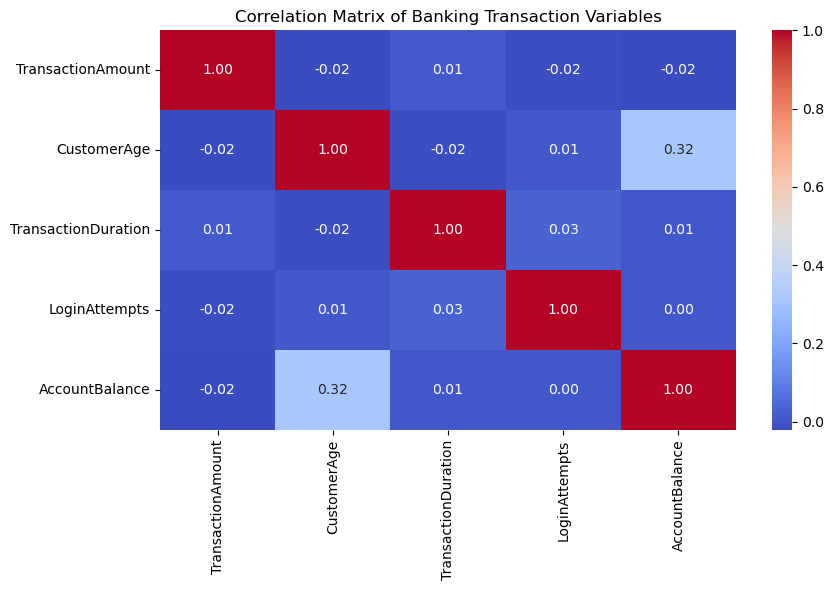

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Banking Transaction Variables')
plt.tight_layout()
plt.show()

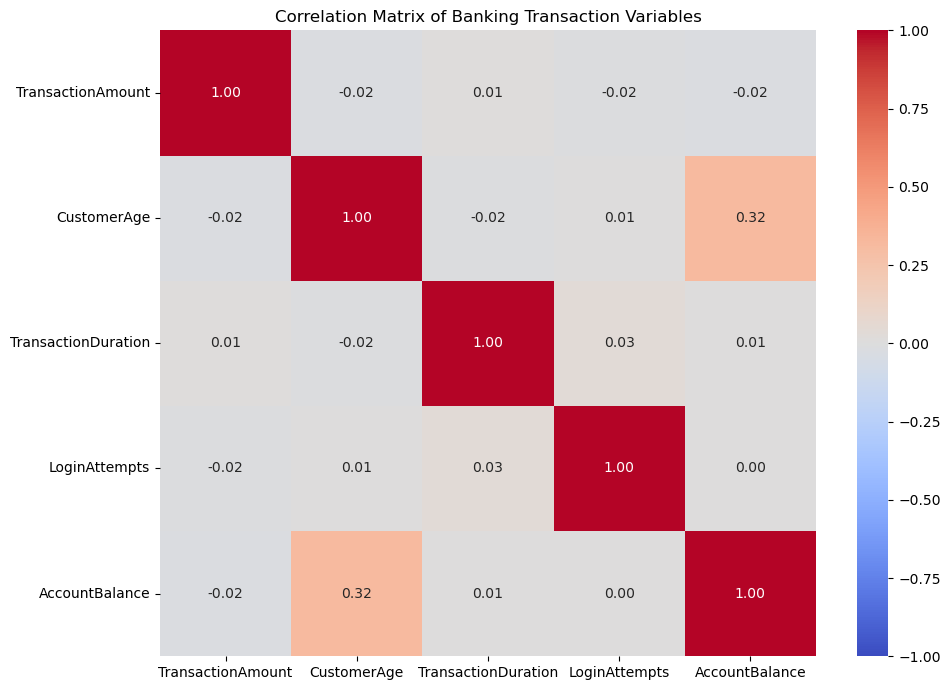

In [122]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Correlation Matrix of Banking Transaction Variables")
plt.tight_layout()
plt.show()

## PROJECT INSIGHTS

Age & Account Balance: Correlation = 0.32, the strongest relationship in the dataset. This indicates a moderate positive association between customer age and account balance.
Transaction Amount & Age: Correlation = -0.02, indicating virtually no linear relationship between customer age and transaction amount.
Transaction Amount & Account Balance: Correlation = -0.02, suggesting that customers with higher balances do not necessarily make larger transactions.
Transaction Duration & Login Attempts: Correlation = 0.03, showing almost no linear relationship between transaction duration and login attempts.
Login Attempts & Account Balance: Correlation = 0.00, indicating no meaningful linear association.
Overall: Most numerical banking variables have very weak correlations, suggesting that transaction behavior is influenced by factors other than these basic numerical variables.

⭐ Resume/project insight
Correlation analysis indicates that most transaction and customer variables are largely independent, while Customer Age and Account Balance show the strongest positive association (r = 0.32). This suggests that demographic characteristics may have some relationship with account holdings, whereas transaction amount and operational variables show limited linear dependence.

In [125]:
# Final dataset check

print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (50000, 26)

Missing values:
TransactionID           0
AccountID               0
TransactionAmount       0
TransactionDate         0
TransactionType         0
Location                0
DeviceID                0
IP Address              0
MerchantID              0
Channel                 0
CustomerAge             0
CustomerOccupation      0
TransactionDuration     0
LoginAttempts           0
AccountBalance          0
AgeGroup                0
Year                    0
Month                   0
MonthName               0
year                    0
HighValueFlag           0
MultipleLoginFlag       0
LongDurationFlag        0
RiskScore               0
RiskCategory            0
HighLoginAttemptFlag    0
dtype: int64

Duplicate rows: 0
